# SirenSense — Vehicle Siren Sound Classification for TinyML Deployment

## Project Summary
This notebook develops a compact TinyML audio classifier for **ambulance_priority**, **fire_rescue_priority**, and **urban_ambient** sound recognition using MFCC features and a lightweight CNN.  
The final model is converted to **INT8 TensorFlow Lite** format and exported as a C header file for deployment on the **Arduino Nano 33 BLE Sense**.

## Objective
Build an on-device emergency-sound recognition system that can distinguish priority-vehicle sirens from normal road noise in real time.

## Workflow
1. Prepare audio file paths and split into train / validation / test sets  
2. Convert each audio clip into fixed-length MFCC features  
3. Train a compact CNN model  
4. Evaluate classification performance using test accuracy and confusion matrices  
5. Quantize the model to INT8 for microcontroller deployment  
6. Export both the trained model and Mel filter bank as C header files

In [1]:
# Core packages used throughout the notebook.
from pathlib import Path

import json
import os
import shutil


import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.regularizers import l2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    DepthwiseConv2D,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
)
from tensorflow.keras.models import Sequential

In [2]:
#%pip install pandas librosa scikit-learn seaborn

## 1. Dataset Preparation

The dataset is stored in the following directory structure:

```text
sounds/
├── ambulance_priority/
├── fire_rescue_priority/
└── urban_ambient/
```

Each subfolder contains `.wav` files for one sound class.  
Files are split **60 / 20 / 20** into train, validation, and test sets using stratified sampling so each split has balanced class proportions.

In [3]:
# ── Dataset root and class names ──────────────────────────────────────────────
AUDIO_ROOT = Path("sounds")
CLASS_LABELS = ["ambulance_priority", "fire_rescue_priority", "urban_ambient"]

# Build a flat dataframe: one row per .wav file with its class label
audio_records = []
for class_label in CLASS_LABELS:
    for wav_path in (AUDIO_ROOT / class_label).glob("*.wav"):
        audio_records.append({"filepath": str(wav_path), "label": class_label})

audio_df = pd.DataFrame(audio_records)

# ── Stratified 60 / 20 / 20 split ────────────────────────────────────────────
# First split off 40 % as a temporary pool, then split that pool 50/50
train_df, temp_df = train_test_split(
    audio_df,
    test_size=0.40,
    stratify=audio_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Train: 360
Validation: 120
Test: 120

Training distribution:
label
ambulance_priority      120
urban_ambient           120
fire_rescue_priority    120
Name: count, dtype: int64

Validation distribution:
label
fire_rescue_priority    40
urban_ambient           40
ambulance_priority      40
Name: count, dtype: int64

Test distribution:
label
fire_rescue_priority    40
ambulance_priority      40
urban_ambient           40
Name: count, dtype: int64


### Dataset Split Visualisation

The bar chart below shows how many audio files land in each split per class, confirming that stratification worked correctly.

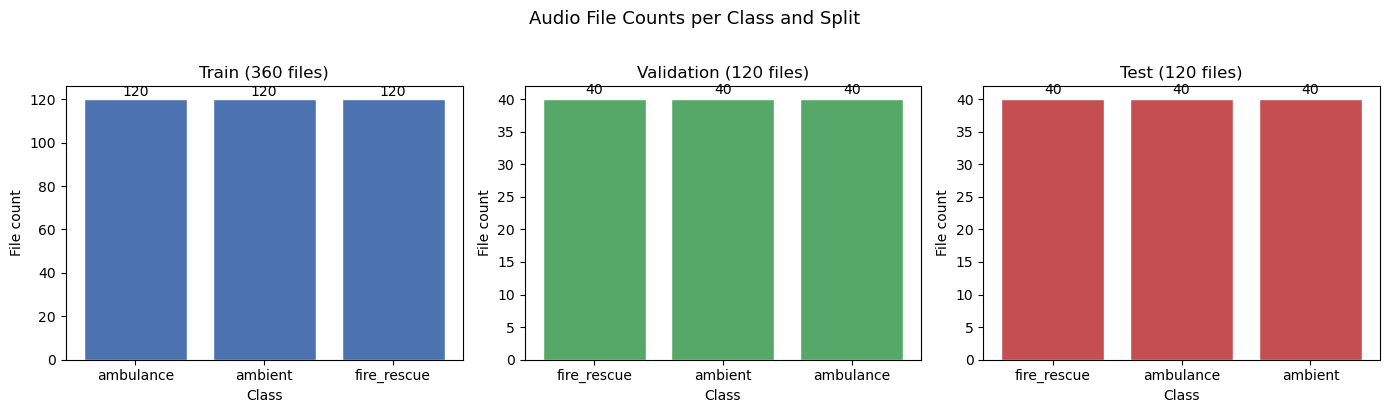

In [4]:
# ── Visualise dataset split distribution across classes ───────────────────────
split_names = ["Train", "Validation", "Test"]
split_frames = [train_df, val_df, test_df]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, split_name, split_frame, color in zip(axes, split_names, split_frames, colors):
    counts = split_frame["label"].value_counts()
    # Use short display names so labels fit on the axis
    short_labels = [lbl.replace("_priority", "").replace("urban_", "") for lbl in counts.index]
    ax.bar(short_labels, counts.values, color=color, edgecolor="white")
    ax.set_title(f"{split_name} ({len(split_frame)} files)", fontsize=12)
    ax.set_ylabel("File count")
    ax.set_xlabel("Class")
    for idx, val in enumerate(counts.values):
        ax.text(idx, val + 0.3, str(val), ha="center", va="bottom", fontsize=10)

plt.suptitle("Audio File Counts per Class and Split", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> peak_normalize_waveform(...)  
> split_clip_into_snippets(...)  
> compute_mfcc_features(...)  
> build_mfcc_dataset(...)

## 2. Feature Extraction Settings

MFCC parameters are chosen to match the TinyML audio pipeline used on the Arduino Nano 33 BLE Sense.

| Parameter | Value | Meaning |
|---|---|---|
| `MFCC_COEFF_COUNT` | 13 | MFCC coefficients per frame |
| `MEL_FILTER_COUNT` | 26 | Mel filter banks |
| `TIME_FRAME_COUNT` | 400 | Time frames per snippet |
| `AUDIO_SAMPLE_RATE` | 16 000 Hz | Target sample rate |
| `FFT_WINDOW_SIZE` | 512 | FFT window (≈ 32 ms) |
| `FRAME_STEP_SIZE` | 128 | Frame shift (≈ 8 ms) |
| `LOW_FREQ_HZ` | 50 Hz | Lowest Mel frequency |
| `HIGH_FREQ_HZ` | 8 000 Hz | Nyquist (SR / 2) |

In [5]:
# Set the MFCC / framing parameters used in both Python training and Arduino deployment.
# These values are intentionally the same as the working notebook logic.
MFCC_COEFF_COUNT = 13
MEL_FILTER_COUNT = 26
TIME_FRAME_COUNT = 400

AUDIO_SAMPLE_RATE = 16000   # 16 kHz audio
FFT_WINDOW_SIZE = 512       # 32 ms analysis window at 16 kHz
FRAME_STEP_SIZE = 128       # 8 ms hop length

LOW_FREQ_HZ = 50
HIGH_FREQ_HZ = AUDIO_SAMPLE_RATE / 2

In [6]:
# ---------------------------------------------------
# 1) Peak-normalise an audio waveform
# ---------------------------------------------------
# This helper keeps the waveform within roughly [-1, 1].
# It does not change the class label or clip duration.
# It only rescales amplitude so that loud and quiet files are
# treated more consistently during MFCC extraction.
def peak_normalize_waveform(audio):
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio

In [7]:
# ---------------------------------------------------
# 2) Split one audio file into fixed-length snippets
# ---------------------------------------------------
# Each training example must have the same number of samples.
# So this helper:
#   - loads one .wav file,
#   - trims leading / trailing silence,
#   - slices it into equal-sized snippets,
#   - pads short remainder segments when necessary.
def split_clip_into_snippets(audio_file):
    y, sr = librosa.load(audio_file, sr=AUDIO_SAMPLE_RATE)

    # Trim leading / trailing silence while preserving the main sound event.
    y, _ = librosa.effects.trim(y, top_db=20)

    # Exact number of samples needed to produce TIME_FRAME_COUNT frames.
    target_length = FFT_WINDOW_SIZE + (TIME_FRAME_COUNT - 1) * FRAME_STEP_SIZE

    audio_array = []

    if len(y) < target_length:
        # Pad short clips so that even short recordings can still contribute one snippet.
        padding_size = target_length - len(y)
        pad_left = padding_size // 2
        pad_right = padding_size - pad_left
        y = np.pad(y, (pad_left, pad_right))
        audio_array.append(y)
    else:
        # Split into full snippets of the target length.
        num_audio_snippets = len(y) // target_length

        for i in range(num_audio_snippets):
            audio_snippet = y[i * target_length : (i + 1) * target_length]
            audio_array.append(audio_snippet)

        # If any trailing samples remain, keep them by padding into one final snippet.
        remainder = len(y) % target_length
        if remainder > 0:
            audio_snippet = y[-remainder:]
            pad_left = (target_length - remainder) // 2
            pad_right = (target_length - remainder) - pad_left
            audio_snippet = np.pad(audio_snippet, (pad_left, pad_right))
            audio_array.append(audio_snippet)

    return audio_array

In [8]:
# ---------------------------------------------------
# 3) Compute MFCCs for a single snippet
# ---------------------------------------------------
# This mirrors the feature settings that will later be used on the Arduino side.
# The returned array shape is roughly (MFCC_COEFF_COUNT, TIME_FRAME_COUNT).
def compute_mfcc_features(data):
    mfcc = librosa.feature.mfcc(
        y=data,
        sr=AUDIO_SAMPLE_RATE,
        n_mfcc=MFCC_COEFF_COUNT,
        n_mels=MEL_FILTER_COUNT,
        n_fft=FFT_WINDOW_SIZE,
        hop_length=FRAME_STEP_SIZE,
        fmin=LOW_FREQ_HZ,
        fmax=HIGH_FREQ_HZ,
        window="hann",
        center=False,
        dct_type=2,
        norm="ortho",
        power=2,
    )
    return mfcc

In [9]:
# ---------------------------------------------------
# 4) Build MFCC features from a dataframe of audio paths
# ---------------------------------------------------
# For every file in the dataframe:
#   1) split it into fixed-length snippets,
#   2) peak-normalise each snippet,
#   3) optionally skip near-silent snippets using RMS energy,
#   4) convert each remaining snippet into an MFCC feature map.

# ── Silence-rejection threshold ───────────────────────────────────────────────
# Snippets whose RMS energy falls below this value are considered silent and
# are skipped during feature extraction to avoid polluting the dataset with
# content-free frames.

SILENCE_RMS_THRESHOLD = 0.02


def build_mfcc_dataset(dataset_df):
    mfccs = []
    labels = []

    for _, row in dataset_df.iterrows():
        audio_path = row["filepath"]
        label = row["label"]
        snippets = split_clip_into_snippets(audio_path)

        for snippet in snippets:
            snippet = peak_normalize_waveform(snippet)

            # Skip snippets that are mostly silence / weak background only.
            rms = np.sqrt(np.mean(snippet ** 2))
            if rms < SILENCE_RMS_THRESHOLD:
                continue

            mfccs.append(compute_mfcc_features(snippet))
            labels.append(label)

    return np.array(mfccs), np.array(labels)

### MFCC Extraction Pipeline

The pipeline converts raw audio into a compact 2-D feature map:

1. **Frame** — split audio into short overlapping windows (≈ 32 ms each)  
2. **Spectrum** — apply FFT to find which frequencies are present in each frame  
3. **Mel scale** — warp frequencies to the Mel scale (more resolution in low frequencies, less in high)  
4. **Log energies** — compress the loudness range with a logarithm  
5. **DCT** — decorrelate the log-Mel energies → produces the MFCC coefficients

## 3. Build MFCC Datasets

Run the feature extraction pipeline on all three splits.

In [10]:
# ---------------------------------------------------
# 5) Run feature extraction for each split
# ---------------------------------------------------
X_train, y_train = build_mfcc_dataset(train_df)
X_val, y_val = build_mfcc_dataset(val_df)
X_test, y_test = build_mfcc_dataset(test_df)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape, "y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

print("Sample labels:", np.unique(y_train))

X_train shape: (360, 13, 400) y_train shape: (360,)
X_val shape: (120, 13, 400) y_val shape: (120,)
X_test shape: (120, 13, 400) y_test shape: (120,)
Sample labels: ['ambulance_priority' 'fire_rescue_priority' 'urban_ambient']


### Example waveform and MFCC view

The next figure helps explain the preprocessing pipeline:
1. the top plot shows a waveform snippet,
2. the bottom plot shows the MFCC representation that is actually fed into the CNN.

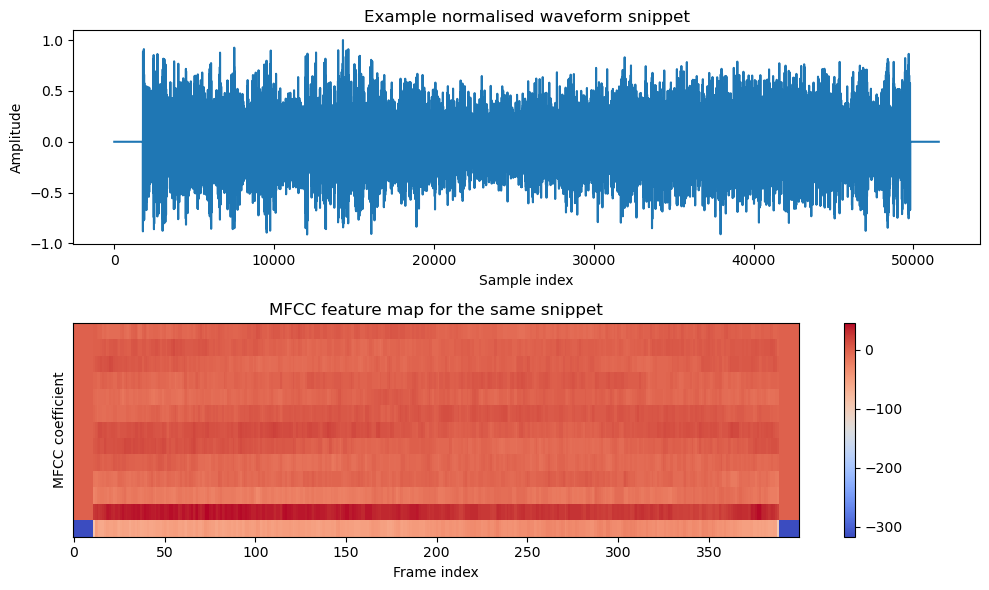

In [11]:
# Visualise one example training snippet and its MFCC representation.
example_path = train_df.iloc[0]["filepath"]
example_snippets = split_clip_into_snippets(example_path)
example_waveform = peak_normalize_waveform(example_snippets[0])
example_mfcc = compute_mfcc_features(example_waveform)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(example_waveform)
axes[0].set_title("Example normalised waveform snippet")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Amplitude")

img = librosa.display.specshow(
    example_mfcc,
    x_axis="frames",
    ax=axes[1]
)
axes[1].set_title("MFCC feature map for the same snippet")
axes[1].set_xlabel("Frame index")
axes[1].set_ylabel("MFCC coefficient")
fig.colorbar(img, ax=axes[1])

plt.tight_layout()
plt.show()

In [12]:
# Encode string labels into integer IDs and then convert them into one-hot vectors.
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

# Fit on the training labels, then reuse the same mapping on validation and test splits.
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

num_classes = len(label_encoder.classes_)

# One-hot encoding is required because the model uses categorical_crossentropy.
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_val_cat = to_categorical(y_val_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

Classes: ['ambulance_priority' 'fire_rescue_priority' 'urban_ambient']
y_train_cat shape: (360, 3)
y_val_cat shape: (120, 3)
y_test_cat shape: (120, 3)


In [13]:
# Add a channel dimension so MFCCs can be processed by Conv2D layers.
# Before: (samples, mfcc, frames)
# After:  (samples, mfcc, frames, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train new shape:", X_train.shape)
print("X_val new shape:", X_val.shape)
print("X_test new shape:", X_test.shape)

X_train new shape: (360, 13, 400, 1)
X_val new shape: (120, 13, 400, 1)
X_test new shape: (120, 13, 400, 1)


In [14]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# A second encoder block is kept here to preserve the original notebook workflow exactly.
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)   # should remain 3
y_train_cat = to_categorical(y_train_enc, num_classes)
y_val_cat   = to_categorical(y_val_enc, num_classes)
y_test_cat  = to_categorical(y_test_enc, num_classes)

print("Classes:", le.classes_)
print("y_train_cat:", y_train_cat.shape)

Classes: ['ambulance_priority' 'fire_rescue_priority' 'urban_ambient']
y_train_cat: (360, 3)


### Sample MFCC Feature Maps

The plots below show one representative MFCC feature map per class.  
Brighter colours indicate higher coefficient energy at that time frame.

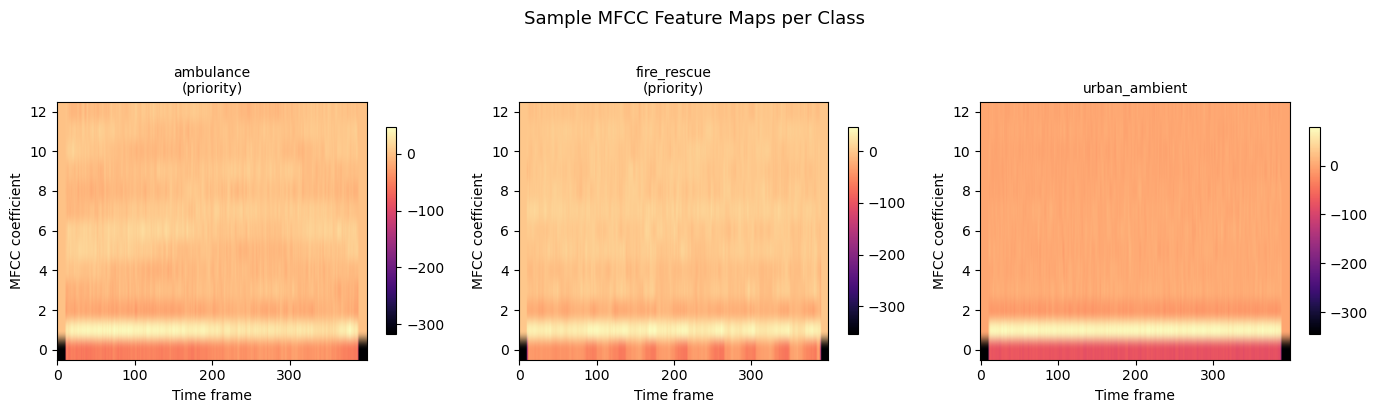

In [15]:
# ── Plot one example MFCC feature map per class ───────────────────────────────
fig, axes = plt.subplots(1, num_classes, figsize=(14, 4))

for class_idx, class_name in enumerate(le.classes_):
    # Find the first snippet belonging to this class
    matching_indices = np.where(y_train_enc == class_idx)[0]
    sample_mfcc = X_train[matching_indices[0], :, :, 0]  # shape (N_MFCC, N_FRAMES)

    img = axes[class_idx].imshow(
        sample_mfcc,
        aspect="auto",
        origin="lower",
        cmap="magma"
    )
    axes[class_idx].set_title(class_name.replace("_priority", "\n(priority)"), fontsize=10)
    axes[class_idx].set_xlabel("Time frame")
    axes[class_idx].set_ylabel("MFCC coefficient")
    fig.colorbar(img, ax=axes[class_idx], shrink=0.8)

plt.suptitle("Sample MFCC Feature Maps per Class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Model Design

A compact CNN is used so the model stays within the memory budget of a microcontroller.

**Architecture overview:**
- Two `Conv2D` blocks extract local spectro-temporal patterns.
- A `SeparableConv2D` is used.
- `GlobalAveragePooling2D` replaces a large `Flatten` + `Dense` stack, keeping the parameter count low.
- `Dropout` (rate 0.2) is applied after the second Conv block and before the final classifier head for regularisation.

### TinyML pipeline overview

This diagram is included only to make the notebook presentation clearer.  
It summarises the end-to-end flow from raw sound file to Arduino deployment.

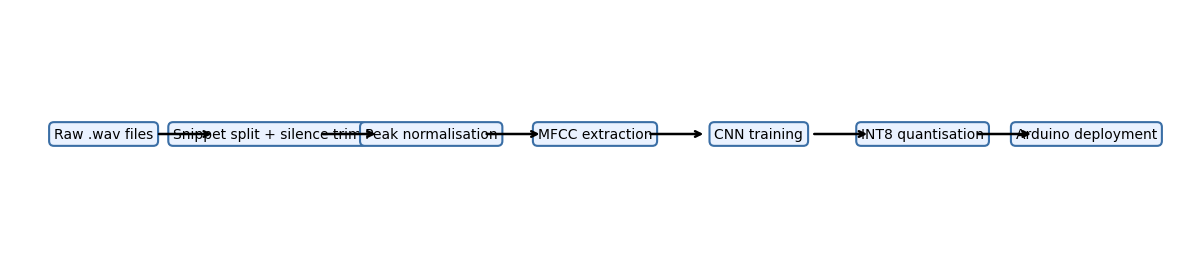

In [16]:
# A simple block diagram for presentation use.
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

steps = [
    "Raw .wav files",
    "Snippet split + silence trim",
    "Peak normalisation",
    "MFCC extraction",
    "CNN training",
    "INT8 quantisation",
    "Arduino deployment"
]
x_positions = np.linspace(0.08, 0.92, len(steps))

for x, label in zip(x_positions, steps):
    ax.text(
        x, 0.5, label,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="#EAF2FF", ec="#3A6EA5", lw=1.5),
        fontsize=10
    )

for x1, x2 in zip(x_positions[:-1], x_positions[1:]):
    ax.annotate(
        "", xy=(x2 - 0.045, 0.5), xytext=(x1 + 0.045, 0.5),
        arrowprops=dict(arrowstyle="->", lw=1.8)
    )

plt.tight_layout()
plt.show()

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# The architecture below is kept identical to the original working notebook.
input_shape = X_train.shape[1:]  # expected to be (13, 400, 1)

model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.SeparableConv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation="softmax")  # 3 output classes
])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 400, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 200, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 200, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 100, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 100, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 3, 100, 16)     │           416 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 50, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,987 (7.76 KB)

 Trainable params: 1,987 (7.76 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from sklearn.utils.class_weight import compute_class_weight

# Early stopping restores the best validation-accuracy weights.
# ReduceLROnPlateau lowers the learning rate if validation loss stalls.
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
]

classes = np.arange(num_classes)  # [0, 1, 2]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("class_weight:", class_weight_dict)

# Keep the original training setup unchanged.
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

class_weight: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3333 - loss: 1.5759 - val_accuracy: 0.3750 - val_loss: 0.9986 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5528 - loss: 0.9879 - val_accuracy: 0.5917 - val_loss: 0.8750 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6528 - loss: 0.8278 - val_accuracy: 0.7833 - val_loss: 0.7173 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6972 - loss: 0.6451 - val_accuracy: 0.7750 - val_loss: 0.5704 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7083 - loss: 0.6097 - val_accuracy: 0.7667 - val_loss: 0.5069 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7333 - loss: 0.5521 - val_accuracy: 0.7833 - val_loss: 0.4561 - learning_rate: 0.0010
Epoch 7/100
1

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.9583333134651184


In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test_enc, y_pred)
print("Confusion matrix:\n", cm)

print("\nReport:\n", classification_report(y_test_enc, y_pred, target_names=le.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Confusion matrix:
 [[38  2  0]
 [ 3 37  0]
 [ 0  0 40]]

Report:
                       precision    recall  f1-score   support

  ambulance_priority       0.93      0.95      0.94        40
fire_rescue_priority       0.95      0.93      0.94        40
       urban_ambient       1.00      1.00      1.00        40

            accuracy                           0.96       120
           macro avg       0.96      0.96      0.96       120
        weighted avg       0.96      0.96      0.96       120



In [21]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.str_('ambulance_priority'): np.int64(120), np.str_('fire_rescue_priority'): np.int64(120), np.str_('urban_ambient'): np.int64(120)}


## 5. Training Curves

Plotting accuracy and loss over all epochs helps identify overfitting or underfitting.

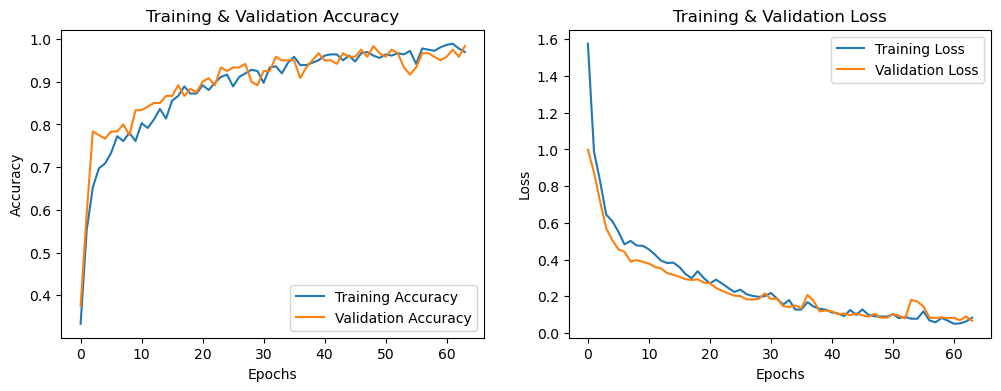

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

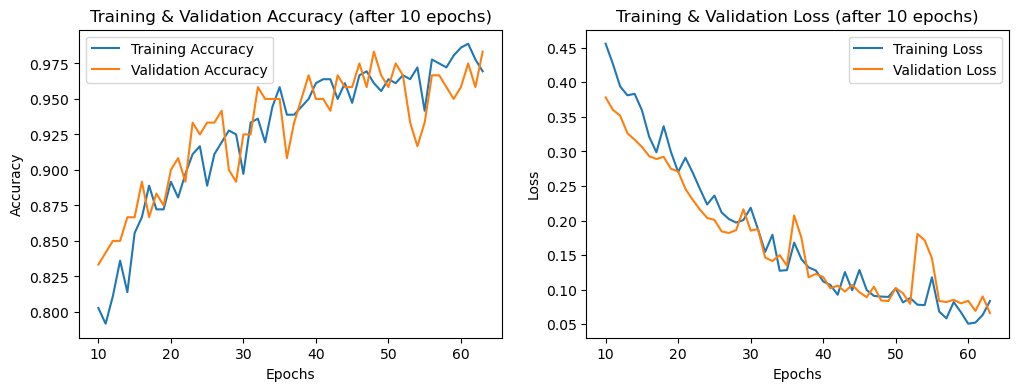

In [23]:
start_epoch = 10

if len(history.history['accuracy']) > start_epoch:
    # Create correct x-axis values (10, 11, 12, ...)
    epochs = range(start_epoch, len(history.history['accuracy']))

    plt.figure(figsize=(12, 4))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'][start_epoch:], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'][start_epoch:], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'Training & Validation Accuracy (after {start_epoch} epochs)')

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'][start_epoch:], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'][start_epoch:], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training & Validation Loss (after {start_epoch} epochs)')

    plt.show()
else:
    print(f"Not enough epochs to plot after epoch {start_epoch}.")

## 6. Test Set Evaluation

Evaluate the trained model on the held-out test split and inspect per-class performance.

In [24]:
# -------------------------
# 3) Evaluate model on the held-out test set
# -------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.12695066630840302
Test accuracy: 0.9583333134651184


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Classification report:

                      precision    recall  f1-score   support

  ambulance_priority       0.93      0.95      0.94        40
fire_rescue_priority       0.95      0.93      0.94        40
       urban_ambient       1.00      1.00      1.00        40

            accuracy                           0.96       120
           macro avg       0.96      0.96      0.96       120
        weighted avg       0.96      0.96      0.96       120



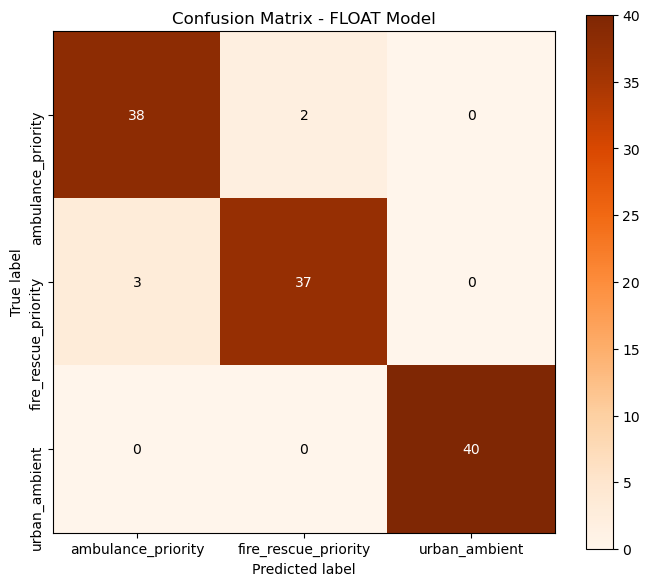

In [25]:
# -------------------------
# 4) Predictions + confusion matrix
# -------------------------
pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)       # predicted class index
y_true = np.argmax(y_test_cat, axis=1)       # true class index

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", cmap="Oranges")
plt.title("Confusion Matrix - FLOAT Model")
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=0)
plt.yticks(tick_marks, le.classes_, rotation=90)

# Write the integer count into each confusion-matrix cell.
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

### Average predicted probability by class

This plot gives a compact summary of how strongly the trained model scores each class on average over the test set.

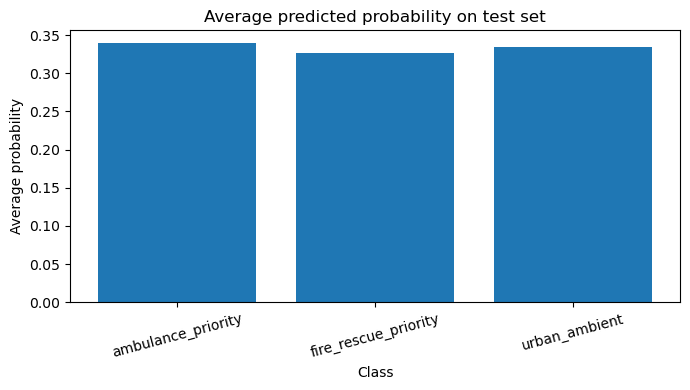

In [26]:
# Average softmax score per class across the test set.
avg_probs = pred_probs.mean(axis=0)

plt.figure(figsize=(7, 4))
plt.bar(le.classes_, avg_probs)
plt.title("Average predicted probability on test set")
plt.xlabel("Class")
plt.ylabel("Average probability")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7. Quantization comparison (Float31, Dynamic, and FULL-integer INT8 for comparing the 3 models)


In [27]:
import tensorflow as tf
import numpy as np
import os
import pandas as pd

# =========================
# 1) Save FLOAT32 TFLite
# =========================
converter_float = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float = converter_float.convert()

float_tflite_path = "vehicle_sound_float32.tflite"
with open(float_tflite_path, "wb") as f:
    f.write(tflite_float)

print("Saved:", float_tflite_path)


# =========================
# 2) Save DYNAMIC RANGE QUANTIZED TFLite
#    (weights quantized, activations remain float during inference)
# =========================
converter_dynamic = tf.lite.TFLiteConverter.from_keras_model(model)
converter_dynamic.optimizations = [tf.lite.Optimize.DEFAULT]
# No representative dataset here -> dynamic range quantization
tflite_dynamic = converter_dynamic.convert()

dynamic_tflite_path = "vehicle_sound_dynamic.tflite"
with open(dynamic_tflite_path, "wb") as f:
    f.write(tflite_dynamic)

print("Saved:", dynamic_tflite_path)


# =========================
# 3) Save FULL INTEGER INT8 QUANTIZED TFLite
# =========================
def representative_dataset():
    # Use a small subset of training data for calibration
    for i in range(min(100, len(X_train))):
        # Ensure float32 and batch dimension
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset

# Force full integer quantization
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()

int8_tflite_path = "vehicle_sound_int8.tflite"
with open(int8_tflite_path, "wb") as f:
    f.write(tflite_int8)

print("Saved:", int8_tflite_path)

INFO:tensorflow:Assets written to: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmp6sfe9y4a/assets


INFO:tensorflow:Assets written to: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmp6sfe9y4a/assets


Saved artifact at '/var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmp6sfe9y4a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 400, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  6079094928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6086140624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6086140432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6088999376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6088999184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089008592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089009168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089007632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089009744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089008976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089009936: TensorSpe

W0000 00:00:1775467774.855803  198988 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.


Saved: vehicle_sound_float32.tflite
INFO:tensorflow:Assets written to: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpg3_cuyk2/assets


...

2026-04-06 17:29:35.194352: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpg3_cuyk2
2026-04-06 17:29:35.194732: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-04-06 17:29:35.194738: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpg3_cuyk2
2026-04-06 17:29:35.198256: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-04-06 17:29:35.217181: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpg3_cuyk2
2026-04-06 17:29:35.223196: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 28845 microseconds.
INFO:tensorflow:Assets written to: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpn7cya737/assets


Saved artifact at '/var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpn7cya737'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 400, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  6079094928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6086140624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6086140432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6088999376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6088999184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089008592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089009168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089007632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089009744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089008976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6089009936: TensorSpe

/opt/anaconda3/envs/tf/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775467775.420210  198988 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1775467775.420222  198988 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-06 17:29:35.420317: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpn7cya737
2026-04-06 17:29:35.420701: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-04-06 17:29:35.420705: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/c5/f9px_zkx2dv7s4x14cb9l5xr0000gr/T/tmpn7cya737
2026-04-06 17:29:35.424187: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-04-06 17:29:35.443238: I tensorflow/cc/save

Saved: vehicle_sound_int8.tflite


INFO: Initialized TensorFlow Lite runtime.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-04-06 17:29:35.584321: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [28]:
artifact_summary = pd.DataFrame({
    "Model Type": [
        "Float32 TFLite",
        "Dynamic Range Quantized TFLite",
        "Full Integer INT8 TFLite"
    ],
    "Filename": [
        float_tflite_path,
        dynamic_tflite_path,
        int8_tflite_path
    ]
})

artifact_summary["Size (bytes)"] = artifact_summary["Filename"].apply(os.path.getsize)
artifact_summary["Size (KB)"] = artifact_summary["Size (bytes)"] / 1024

artifact_summary

,Model Type,Filename,Size (bytes),Size (KB)
0,Float32 TFLite,vehicle_sound_float32.tflite,12520,12.226562
1,Dynamic Range Quantized TFLite,vehicle_sound_dynamic.tflite,9168,8.953125
2,Full Integer INT8 TFLite,vehicle_sound_int8.tflite,9144,8.929688


In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_tflite_model(tflite_path, X_test, y_test_cat, class_names=None, verbose=True):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    input_dtype = input_details[0]["dtype"]
    output_dtype = output_details[0]["dtype"]

    y_true = np.argmax(y_test_cat, axis=1)
    y_pred = []

    # Quantization params
    input_scale, input_zero_point = input_details[0]["quantization"]
    output_scale, output_zero_point = output_details[0]["quantization"]

    for i in range(len(X_test)):
        x = X_test[i:i+1].astype(np.float32)

        # Quantize input if model expects int8
        if input_dtype == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
            x = np.clip(x, -128, 127)

        interpreter.set_tensor(input_index, x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_index)

        # Dequantize output if needed
        if output_dtype == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = np.argmax(output, axis=1)[0]
        y_pred.append(pred)

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    if verbose:
        print(f"\nModel: {tflite_path}")
        print(f"Accuracy: {acc:.4f}")
        if class_names is not None:
            print("\nClassification report:")
            print(classification_report(y_true, y_pred, target_names=class_names))
        else:
            print("\nClassification report:")
            print(classification_report(y_true, y_pred))

    return acc, cm, y_true, y_pred

In [30]:
class_names = list(le.classes_)  # or e.g. ["ambulance_priority", "fire_rescue_priority", "urban_ambient"]

results = []

for model_type, path in [
    ("Float32 TFLite", float_tflite_path),
    ("Dynamic Range Quantized TFLite", dynamic_tflite_path),
    ("Full Integer INT8 TFLite", int8_tflite_path),
]:
    acc, cm, y_true, y_pred = evaluate_tflite_model(
        path, X_test, y_test_cat, class_names=class_names, verbose=True
    )
    results.append({
        "Model Type": model_type,
        "Filename": path,
        "Size (bytes)": os.path.getsize(path),
        "Size (KB)": os.path.getsize(path) / 1024,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results)
results_df


Model: vehicle_sound_float32.tflite
Accuracy: 0.9583

Classification report:
                      precision    recall  f1-score   support

  ambulance_priority       0.93      0.95      0.94        40
fire_rescue_priority       0.95      0.93      0.94        40
       urban_ambient       1.00      1.00      1.00        40

            accuracy                           0.96       120
           macro avg       0.96      0.96      0.96       120
        weighted avg       0.96      0.96      0.96       120


Model: vehicle_sound_dynamic.tflite
Accuracy: 0.9583

Classification report:
                      precision    recall  f1-score   support

  ambulance_priority       0.93      0.95      0.94        40
fire_rescue_priority       0.95      0.93      0.94        40
       urban_ambient       1.00      1.00      1.00        40

            accuracy                           0.96       120
           macro avg       0.96      0.96      0.96       120
        weighted avg       0.96  

/opt/anaconda3/envs/tf/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Applying 1 TensorFlow Lite delegate(s) lazily.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
VERBOSE: XNNPack weight cache not enabled.
VERBOSE: Replacing 11 out of 11 node(s) with delegate (TfLiteXNNPackDelegate) node, yielding 1 partitions for subgraph 0.
INFO: Successfully applied the default TensorFlow Lite delegate indexed at 0.
 *NOTE*: because a delegate has been applied, the precision of computations should be unchanged, but the exact output tensor values may have changed. If such output values are checked in your code, like in your tests etc., please consid

,Model Type,Filename,Size (bytes),Size (KB),Accuracy
0,Float32 TFLite,vehicle_sound_float32.tflite,12520,12.226562,0.958333
1,Dynamic Range Quantized TFLite,vehicle_sound_dynamic.tflite,9168,8.953125,0.958333
2,Full Integer INT8 TFLite,vehicle_sound_int8.tflite,9144,8.929688,0.950000


/opt/anaconda3/envs/tf/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Applying 1 TensorFlow Lite delegate(s) lazily.
VERBOSE: XNNPack weight cache not enabled.
VERBOSE: Replacing 11 out of 11 node(s) with delegate (TfLiteXNNPackDelegate) node, yielding 1 partitions for subgraph 0.
INFO: Successfully applied the default TensorFlow Lite delegate indexed at 0.
 *NOTE*: because a delegate has been applied, the precision of computations should be unchanged, but the exact output tensor values may have changed. If such output values are checked in your code, like in your tests etc., please consider increasing error tolerance for the check.
/opt/anacon

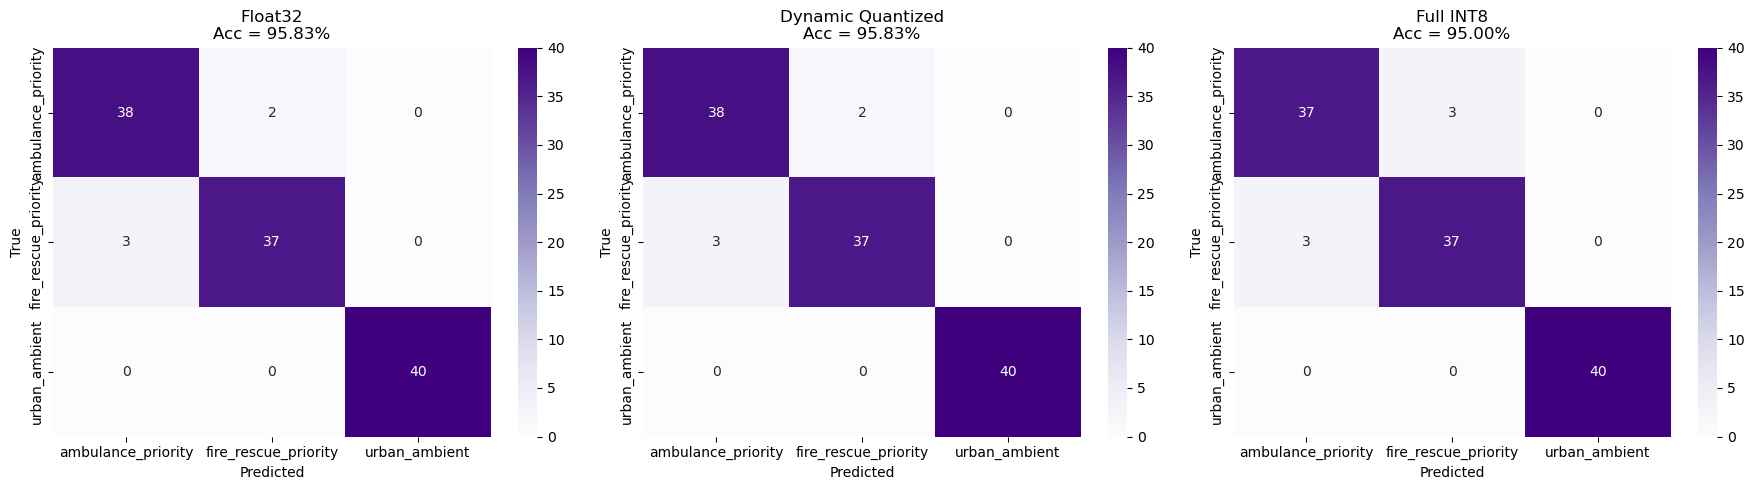

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, path) in zip(axes, [
    ("Float32", float_tflite_path),
    ("Dynamic Quantized", dynamic_tflite_path),
    ("Full INT8", int8_tflite_path),
]):
    acc, cm, _, _ = evaluate_tflite_model(
        path, X_test, y_test_cat, class_names=class_names, verbose=False
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Purples",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_xticklabels(class_names, rotation=0)
    ax.set_yticklabels(class_names, rotation=90)

    ax.set_title(f"{title}\nAcc = {acc*100:.2f}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


## 8. Export the INT8 model as a C header file


In [32]:
# Convert the exported .tflite file into a C header so Arduino can include it directly.
tflite_path = "vehicle_sound_int8.tflite"
header_path = "vehicle_sound_model.h"
array_name = "vehicle_sound_model"

with open(tflite_path, "rb") as f:
    data = f.read()

with open(header_path, "w") as f:
    f.write("#pragma once\n\n")
    f.write(f"const unsigned char {array_name}[] = {{\n")

    for i, b in enumerate(data):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"0x{b:02x}, ")
        if i % 12 == 11:
            f.write("\n")

    f.write("\n};\n")
    f.write(f"const unsigned int {array_name}_len = {len(data)};\n")

print("Saved header:", header_path, "bytes:", len(data))

Saved header: vehicle_sound_model.h bytes: 9144


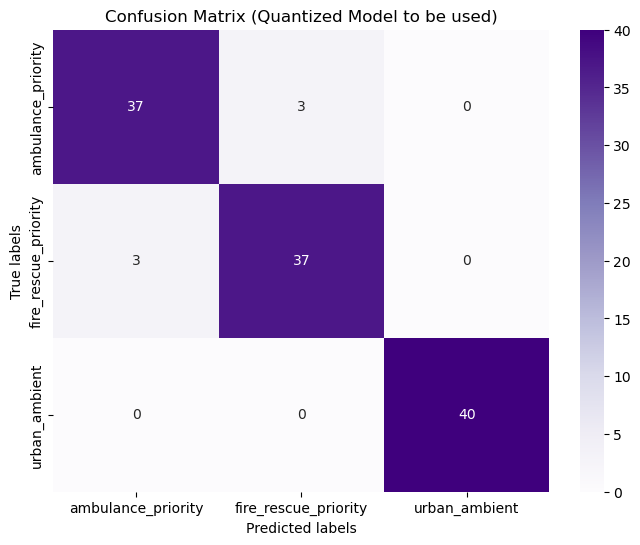

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_q = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_q, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Purples')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Quantized Model to be used)')
plt.show()


## 9. Generate the Mel Filter Bank


In [34]:
# Create the Mel filter bank using the same parameters used during training.
mel_filter_bank = librosa.filters.mel(
    sr=AUDIO_SAMPLE_RATE,
    n_mels=MEL_FILTER_COUNT,
    n_fft=FFT_WINDOW_SIZE,
    fmin=LOW_FREQ_HZ,
    fmax=HIGH_FREQ_HZ
)

# Format the filter-bank matrix as a C array for Arduino.
c_array = "const float mel_filter_bank[NUM_MEL_FILTERS][N_FFT / 2 + 1] = {\n"
for row in mel_filter_bank:
    c_array += "    {" + ", ".join(map(str, row)) + "},\n"
c_array = c_array.rstrip(",\n") + "\n};"

with open("mel_filter_bank.h", "w") as f:
    f.write("#ifndef MEL_FILTER_BANK_H\n")
    f.write("#define MEL_FILTER_BANK_H\n\n")
    f.write("#define NUM_MEL_FILTERS {}\n".format(mel_filter_bank.shape[0]))
    f.write("#define N_FFT {}\n\n".format((mel_filter_bank.shape[1] - 1) * 2))
    f.write(c_array + "\n\n")
    f.write("#endif // MEL_FILTER_BANK_H\n")

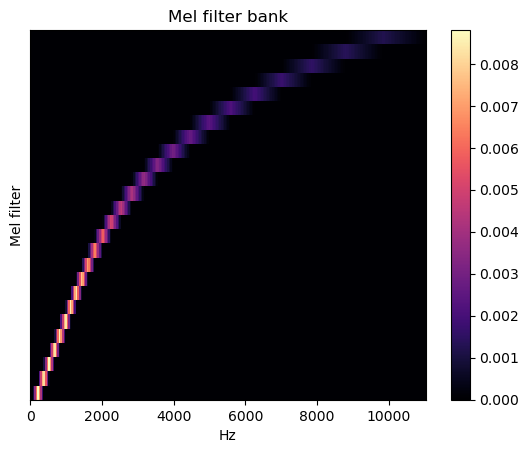

In [36]:
fig, ax = plt.subplots()
img = librosa.display.specshow(mel_filter_bank, x_axis='linear', ax=ax)
ax.set(ylabel='Mel filter', title='Mel filter bank')
fig.colorbar(img, ax=ax)


## END OF CODE
